### 1d. Do animals have fewer states then gradually seperate out all 4 wells?

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from scipy import stats
import starbars

cmap = mpl.colormaps['cool']

In [3]:
from spyglass.shijiegu.pairwiseDecode import replay_transitions,categorized_replay_transitions,behavior_transitions,behavior_transitions_count,findXCorrAllDays
from spyglass.shijiegu.changeOfMind_byTransition import find_COM_transitions, info2matrix

from spyglass.shijiegu.Analysis_SGU import ChangeofMind
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition

[2025-10-12 13:58:53,794][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [81]:
def return_nonneighbor_alpha_beta(C_behavior):

    nonneighbors = {0:[2,3], 1:[2,3], 2:[0,1], 3:[0,1]}
    alpha = {}
    
    for row_ind in range(4):
        n_ind = nonneighbors[row_ind]
        alpha[row_ind] = [C_behavior[row_ind, n_ind[0]], C_behavior[row_ind, n_ind[1]]]

    return alpha

### Plot beta distribution

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Define the shape parameters (alpha and beta)
# These parameters determine the shape of the distribution
alpha = 2
beta_param = 5

def plot_beta(a, b, color, axe):
    # Generate x-values (the range over which to plot the PDF)
    # The Beta distribution is defined on the interval [0, 1]
    x = np.linspace(0, 1, 100)
    
    # Calculate the PDF for each x-value
    pdf_values = beta.pdf(x, a, b)
    
    # Plot the Beta distribution
    axe.plot(x, pdf_values, color = color);


### legend

In [67]:
colors = np.array([["","C0","blueviolet","violet"],
          ["C1","","yellow","olive"],
          ["forestgreen","lime","","teal"],
          ["maroon","crimson","chocolate",""]])

# neighboring transitions are colored in orange, blue, others in grey
colors = np.array([["","C1","grey","grey"],
          ["C1","","grey","grey"],
          ["grey","grey","","C1"],
          ["grey","grey","C1",""]])

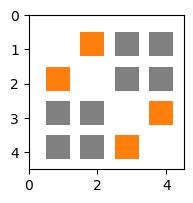

In [7]:
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 1, figsize=(2, 2),sharex=True)
for i in range(4):
    for j in range(4):
        if i == j:
            continue
        rect_ij = patches.Rectangle((j-0.5 + 1, i-0.5 + 1), 0.7, 0.7, linewidth=0.1, facecolor=colors[i,j])
        axes.add_patch(rect_ij)

axes.set_ylim(0, 4.5)
axes.set_xlim(0, 4.5)
axes.invert_yaxis()  # Invert the x-axis

In [68]:
def figure2_state(animal, animal_save_name, dates_to_plot, datafolder, pre, post):
    """all behavior"""
    C_behavior_all, C_behavior_reward_all = behavior_transitions_count(animal,dates_to_plot)
    
    num_trials = [int(np.sum(C_behavior_all[C])) for C in C_behavior_all]
    
    data = {}
    data["num_trials"] = num_trials
    data["C_behavior"] = C_behavior_all

    data["pre"] = pre
    data["post"] = post
    
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'

    file_path = f"{output_folder}/{animal_save_name}_state_analysis.pickle"
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")

    return success

### animals

In [56]:
success = {}

In [59]:
animal = 'Molly'
animal_save_name = 'Molly'
dates_to_plot = ['20220415','20220416','20220417','20220418','20220419','20220420']
datafolder = '/stelmo/shijie/behavior_pilot/Batch1/' #f'/stelmo/shijie/behavior_pilot/Batch1/{animal}'
pre = ['20220415','20220416','20220417','20220418','20220419']
post = ['20220420']

success[animal_save_name] = figure2_state(animal, animal_save_name, dates_to_plot, datafolder, pre, post)

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Molly_state_analysis.pickle


In [60]:
animal = 'Eliot'
animal_save_name = 'Eliot'
dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/'
pre = ['20221018','20221019','20221020','20221021','20221022','20221023']
post = ['20221024','20221025','20221026']

success[animal_save_name] = figure2_state(animal, animal_save_name, dates_to_plot, datafolder, pre, post)

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Eliot_state_analysis.pickle


In [61]:
animal = 'Klein'
animal_save_name = 'Klein'
# " 20231110 has problems "
dates_to_plot = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']

pre = ['20231101','20231102','20231103','20231104','20231105','20231106','20231107','20231108']
post = ['20231109','20231111']

success[animal_save_name] = figure2_state(animal, animal_save_name, dates_to_plot, datafolder, pre, post)

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Klein_state_analysis.pickle


In [62]:
animal = 'Lewis'
animal_save_name = 'Lewis1'
dates_to_plot = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114']

pre = ['20240105','20240106','20240107','20240108','20240109']
post = ['20240110','20240113','20240114']

success[animal_save_name] = figure2_state(animal, animal_save_name, dates_to_plot, datafolder, pre, post)

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Lewis1_state_analysis.pickle


In [63]:
animal = 'Julio'
animal_save_name = 'Julio'
dates_to_plot = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
pre = ['20230731','20230801','20230802','20230803','20230804',
       '20230805','20230806']
post = ['20230807','20230808','20230809','20230810','20230811']

success[animal_save_name] = figure2_state(animal, animal_save_name, dates_to_plot, datafolder, pre, post)

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Julio_state_analysis.pickle


### condensed plots:

In [84]:
# load all rats dates_to_plot, pre, post, P_behavior, COM_wouldhave_all,  COM_all

animals = ["Molly","Eliot","Klein","Lewis1","Julio"]

data = {}
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
for animal in animals:
    file_path = f"{output_folder}/{animal}_state_analysis.pickle"
    with open(file_path, 'rb') as file:
        data[animal] = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")
        

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/Molly_state_analysis.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/Eliot_state_analysis.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/Klein_state_analysis.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/Lewis1_state_analysis.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/Julio_state_analysis.pickle


### 1) direct beta distribution plots

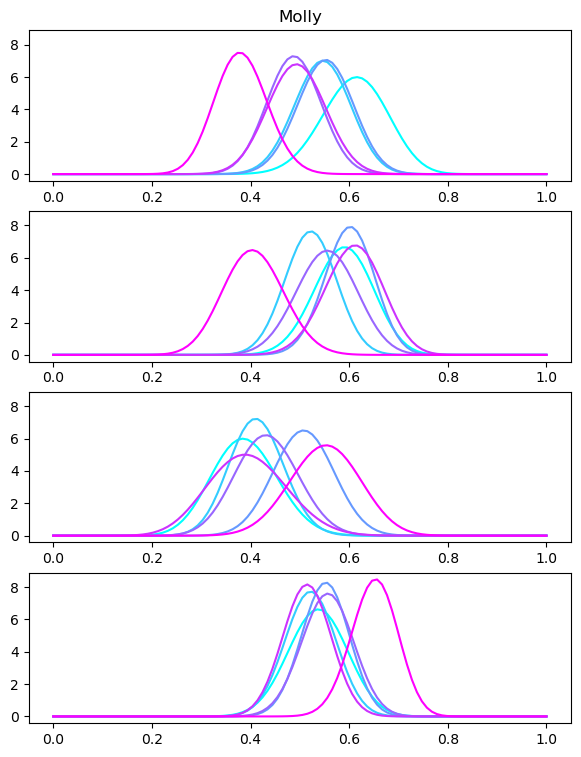

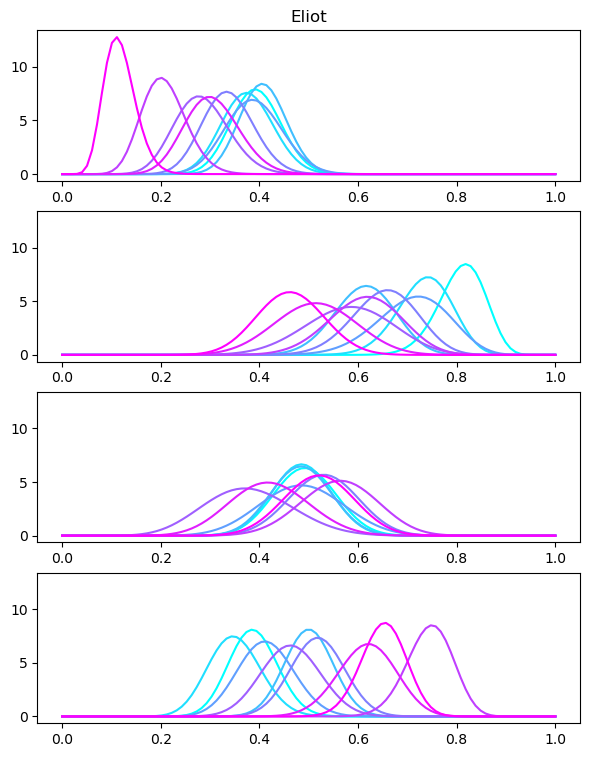

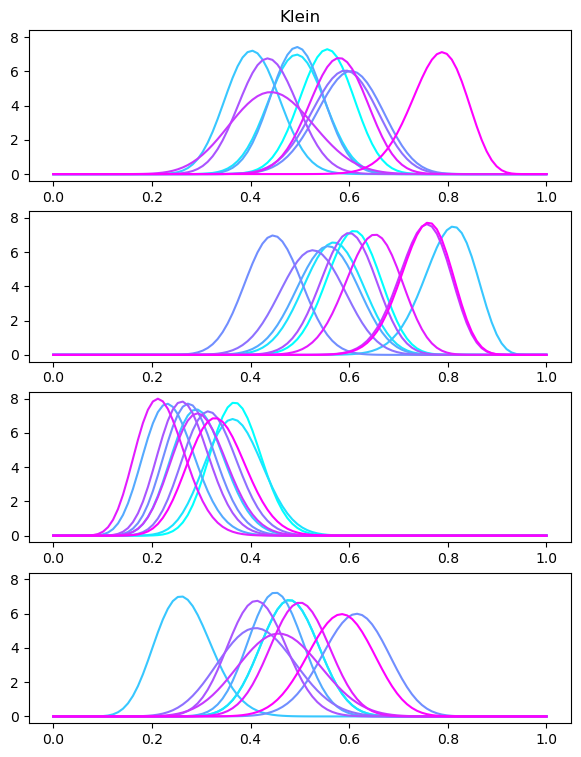

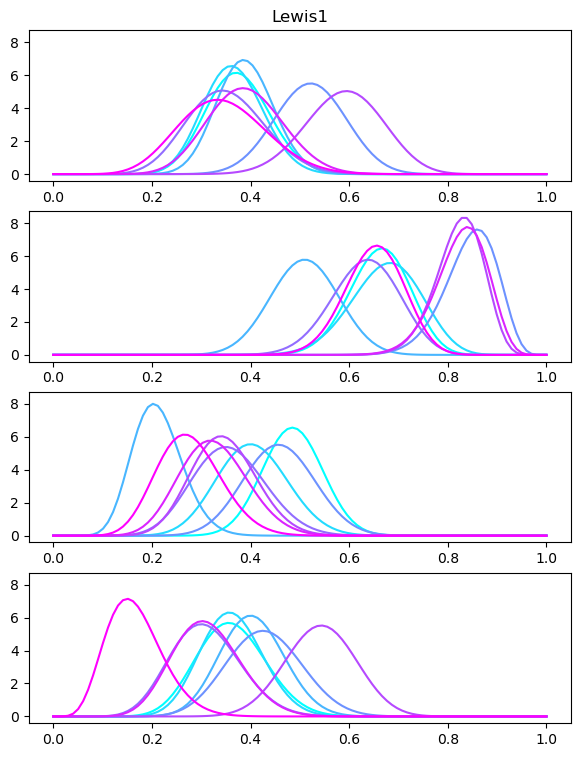

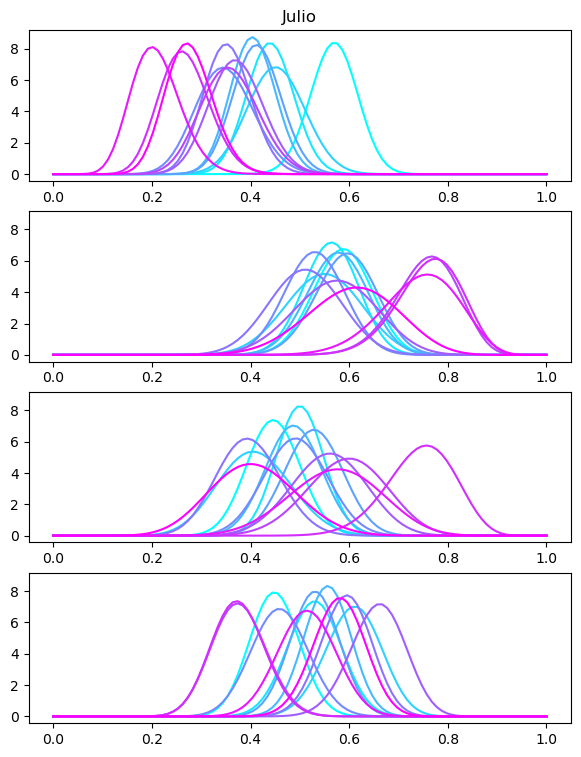

In [98]:
for animal in animals:

    fig, axes = plt.subplots(4, 1, figsize=(7, 9),sharey = True)
    data_animal = data[animal]
    
    (pre, post,
     C_behavior) = (
         data_animal["pre"], data_animal["post"],
         data_animal["C_behavior"]
     )
    dates_to_plot = pre + post
    
    ####
    pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
    post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
    ####
    
    norm = Normalize(vmin=0, vmax=len(pre)+len(post)-1)
    
    for ind in pre_ind + post_ind:
        d = dates_to_plot[ind]
        alphabeta = return_nonneighbor_alpha_beta(C_behavior[d])

        for arm in range(4):
            a, b = alphabeta[arm]
            plot_beta(b, a, cmap(norm(ind)), axes[arm]);

    axes[0].set_title(animal);

    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure1/beta_distribution{animal}"
    plt.savefig(file_path + ".pdf")
    plt.savefig(file_path + ".png")

Molly/Eliot/Julio: 3 4 2 1 -> Arm 4 and Arm 1
Klein/Lewis: Arm 2 and Arm 3

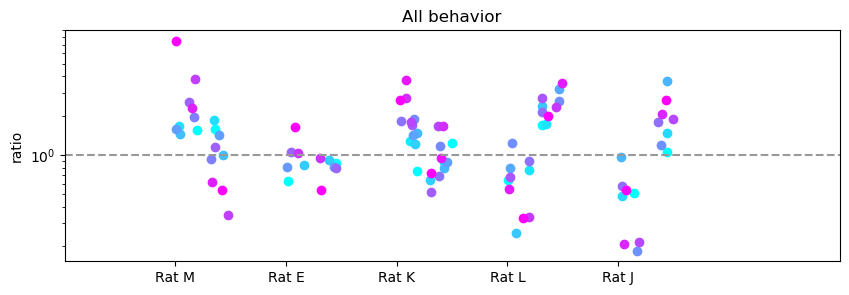

In [146]:
fig, axes = plt.subplots(1, 1, figsize=(10, 3),sharey = True)

arms_animal = {"Eliot":[0,3],"Molly":[0,3],"Julio":[0,3],"Klein":[1,2],"Lewis1":[1,2]}


animal_ind = 0
for animal in ["Eliot", "Molly", "Julio", "Klein", "Lewis1"]:#animals:

    
    data_animal = data[animal]
    
    (pre, post,
     C_behavior) = (
         data_animal["pre"], data_animal["post"],
         data_animal["C_behavior"]
     )
    dates_to_plot = pre + post
    
    ####
    pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
    post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
    ####
    
    norm = Normalize(vmin=0, vmax=len(pre)+len(post)-1)
    
    for ind in pre_ind + post_ind:
        d = dates_to_plot[ind]
        alphabeta = return_nonneighbor_alpha_beta(C_behavior[d])

        arm_count = 0
        for arm in arms_animal[animal]:
            a, b = alphabeta[arm]
            ratio = a/b
            x_shift = 0.3*arm_count + np.random.rand(1)/5
            axes.scatter(np.zeros_like(ratio) + animal_ind + x_shift, ratio, color = cmap(norm(ind)))
            arm_count += 1


    animal_ind += 1

# log scale
axes.set_yscale('log')

axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0] for animal in animals]);
axes.set_xlim([-1,len(animals) + 1]);
axes.set_title("All behavior")
axes.set_ylabel("ratio")

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure1/beta_distribution_summary"
plt.savefig(file_path + ".pdf")
plt.savefig(file_path + ".png")

### Linear regression

In [115]:
import statsmodels.api as sm

In [119]:
def do_linear_regression(x,y):
    X = sm.add_constant(x)

    model = sm.OLS(y, X)
    results = model.fit()

    predicted_Y = results.predict(X)

    return model, results, predicted_Y

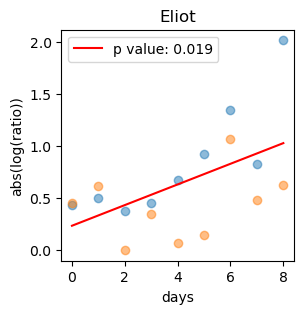

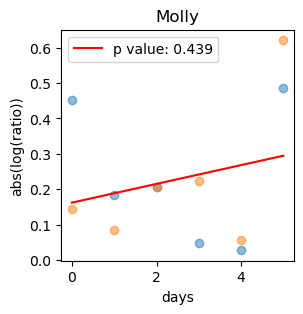

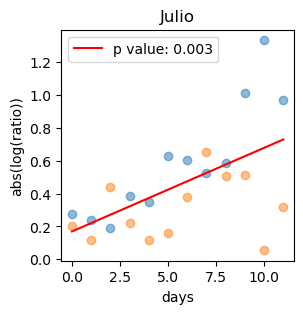

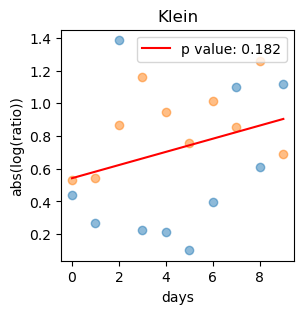

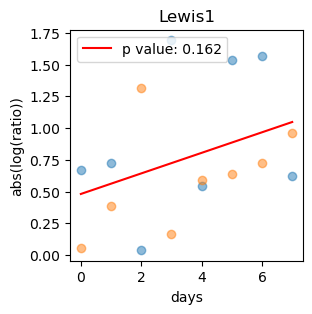

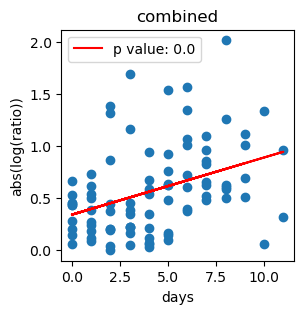

In [148]:
arms_animal = {"Eliot":[0,3],"Molly":[0,3],"Julio":[0,3],"Klein":[1,2],"Lewis1":[1,2]}

combined_x = []
combined_y = []
animal_ind = 0
for animal in ["Eliot", "Molly", "Julio", "Klein", "Lewis1"]:#animals:
    fig, axes = plt.subplots(1, 1, figsize=(3, 3),sharey = True)

    
    data_animal = data[animal]
    
    (pre, post,
     C_behavior) = (
         data_animal["pre"], data_animal["post"],
         data_animal["C_behavior"]
     )
    dates_to_plot = pre + post
    
    ####
    pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
    post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
    ####
    
    norm = Normalize(vmin=0, vmax=len(pre)+len(post)-1)

    x = []
    y = []
    for ind in pre_ind + post_ind:
        d = dates_to_plot[ind]
        alphabeta = return_nonneighbor_alpha_beta(C_behavior[d])

        arm_count = 0
        for arm in arms_animal[animal]:
            a, b = alphabeta[arm]
            ratio = np.abs(np.log(a/b))
            
            x.append(ind)
            y.append(ratio)
            axes.scatter(ind, ratio, color = f'C{arm_count}', alpha = 0.5)#color = cmap(norm(ind)))
            arm_count += 1

    #### linear regression section
    model, results, Y =  do_linear_regression(x,y)
    #X = np.arange(0,len(pre)+len(post))
    plt.plot(x, Y, color='red',label = f"p value: {np.round(results.pvalues[1],3)}")
    plt.legend()
    ####
    combined_x.append(x)
    combined_y.append(y)

    animal_ind += 1
    axes.set_title(animal)
    axes.set_xlabel("days")
    axes.set_ylabel("abs(log(ratio))")


    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure1/beta_distribution_GLM_{animal}"
    plt.savefig(file_path + ".pdf")
    plt.savefig(file_path + ".png")

fig, axes = plt.subplots(1, 1, figsize=(3, 3),sharey = True)
x = np.concatenate(combined_x)
y = np.concatenate(combined_y)

axes.scatter(x,y)
#### linear regression section
model, results, Y =  do_linear_regression(x,y)
#X = np.arange(0,len(pre)+len(post))
plt.plot(x, Y, color='red',label = f"p value: {np.round(results.pvalues[1],3)}")
plt.legend()
####

axes.set_title("combined")
axes.set_xlabel("days")
axes.set_ylabel("abs(log(ratio))")

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure1/beta_distribution_GLMcombined"
plt.savefig(file_path + ".pdf")
plt.savefig(file_path + ".png")